In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [123]:
data1nomod = pd.read_csv('/home/kale-chen/Documents/PET/TemperatureStudies/FirstEverTesting/test_temperature_acq_10min_lowint_no_mod_coinc.dat', header=None, sep='\t').to_numpy()
firsttime = data1nomod[0, 2]
data1nomod[:, 2] = (data1nomod[:, 2] - firsttime) / 1e12
data1nomod[:, 7] = (data1nomod[:, 7] - firsttime) / 1e12
data2nomod = pd.read_csv('/home/kale-chen/Documents/PET/TemperatureStudies/FirstEverTesting/test_temperature_acq_10min_lowint_no_mod2_coinc.dat', header=None, sep='\t').to_numpy()
firsttime = data2nomod[0, 2]
data2nomod[:, 2] = (data2nomod[:, 2] - firsttime) / 1e12 + 600
data2nomod[:, 7] = (data2nomod[:, 7] - firsttime) / 1e12 + 600
datanomod = np.concatenate((data1nomod, data2nomod))
datamodded = pd.read_csv('/home/kale-chen/Documents/PET/TemperatureStudies/FirstEverTesting/test_temperature_acq_20min_lowint_modded_coinc.dat', header=None, sep='\t').to_numpy()
firsttime = datamodded[0, 2]
datamodded[:, 2] = (datamodded[:, 2] - firsttime) / 1e12
datamodded[:, 7] = (datamodded[:, 7] - firsttime) / 1e12
print(len(data1nomod), len(data2nomod), len(datanomod))
print(len(datanomod), len(datamodded))
datanomod = datanomod[:, [2, 3, 4, 7, 8, 9]]
datamodded = datamodded[:, [2, 3, 4, 7, 8, 9]]

times = []
temps = []
with open('/home/kale-chen/Documents/PET/TemperatureStudies/FirstEverTesting/temperaturelog.txt', 'r') as f:
    index = -1
    for line in f:
        if 'Temperature log at' in line:
            time = float(line.split()[-1])
            times.append(time)
            temps.append([])
            index += 1
        elif line[0] == '(':
            #print(line.split())
            temps[index].append(float(line.split()[-1]))
        #print(line)
temps = np.array(temps)
print(temps.shape)

7678 7501 15179
15179 15171
(40, 8)


Uncertainty on popt1[0]: 0.008342
Uncertainty on popt2[0]: 0.009027


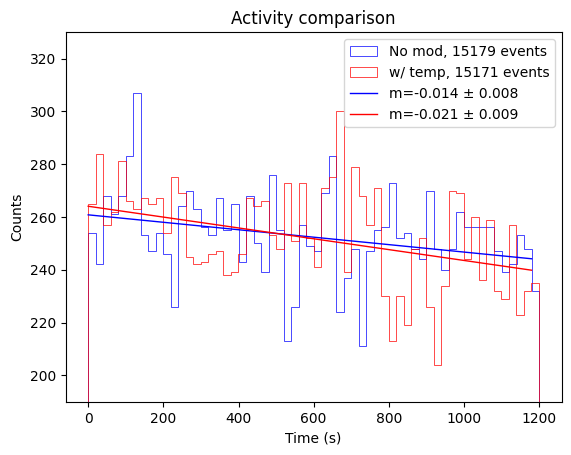

In [144]:
def linear(x, a, b):
    return a * x + b

hist1 = plt.hist(datanomod[:, 0], bins=60, color='blue', histtype='step', linewidth = 0.5, label='No mod, 15179 events')
hist2 = plt.hist(datamodded[:, 0], bins=60, color='red', histtype='step', linewidth = 0.5, label='w/ temp, 15171 events')
popt1, pcov1 = curve_fit(linear, hist1[1][:-1][:50], hist1[0][:50], p0 = [-0.012, 135])
popt2, pcov2 = curve_fit(linear, hist2[1][:-1][10:], hist2[0][10:])
uncertainty_popt1_0 = np.sqrt(pcov1[0, 0])
uncertainty_popt2_0 = np.sqrt(pcov2[0, 0])
print(f"Uncertainty on popt1[0]: {uncertainty_popt1_0:.6f}")
print(f"Uncertainty on popt2[0]: {uncertainty_popt2_0:.6f}")

plt.plot(hist1[1][:-1], linear(hist1[1][:-1], *popt1), color='blue', linewidth = 1, label=f'm={popt1[0]:.3f} ± {uncertainty_popt1_0:.3f}')
plt.plot(hist2[1][:-1], linear(hist2[1][:-1], *popt2), color='red', linewidth = 1, label=f'm={popt2[0]:.3f} ± {uncertainty_popt2_0:.3f}')
plt.ylim(190, 330)
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Counts')
plt.title('Activity comparison')
plt.show()

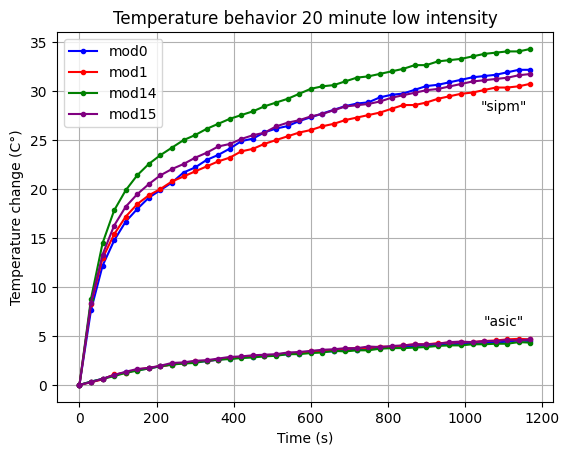

In [120]:
times = np.array(times)
times = times - times[0]
plt.plot(times, temps[:, 0] - temps[0, 0], 'o-', color = 'blue', markersize = 3, label = 'mod0')
plt.plot(times, temps[:, 1] - temps[0, 1], 'o-', color = 'blue', markersize = 3)
plt.plot(times, temps[:, 2] - temps[0, 2], 'o-', color = 'red', markersize = 3, label = 'mod1')
plt.plot(times, temps[:, 3] - temps[0, 3], 'o-', color = 'red', markersize = 3)
plt.plot(times, temps[:, 4] - temps[0, 4], 'o-', color = 'green', markersize = 3, label = 'mod14')
plt.plot(times, temps[:, 5] - temps[0, 5], 'o-', color = 'green', markersize = 3)
plt.plot(times, temps[:, 6] - temps[0, 6], 'o-', color = 'purple', markersize = 3, label = 'mod15')
plt.plot(times, temps[:, 7] - temps[0, 7], 'o-', color = 'purple', markersize = 3)
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Temperature change (C°)')
plt.text(1040, 28, '"sipm"')
plt.text(1050, 6, '"asic"')
plt.title('Temperature behavior 20 minute low intensity')
plt.grid()
plt.show()

[ 2196.          1538.00000513 -1407.00000262 ...  4172.07957071
 -1229.86421047   384.03413782]


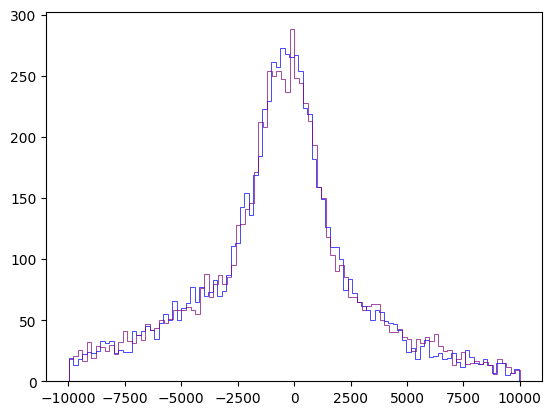

In [133]:
timediffs = (datamodded[:, 3] - datamodded[:, 0]) * 1e12
print(timediffs)
plt.hist(timediffs[0:timediffs.size//2], bins=100, color='blue', histtype='step', linewidth = 0.5)
plt.hist(timediffs[timediffs.size//2:], bins=100, color='purple', histtype='step', linewidth = 0.5)
plt.show()

In [134]:
# Event counts per channel
eventcounts = np.zeros(256, dtype = np.int32)

#ids = np.asarray(chunk[:, [0, 1]], dtype = np.int32)
ids = np.asarray(datamodded[:, [1, 3]], dtype = np.int32)
ids[:, 0] = ids[:, 0] + 3072
np.add.at(eventcounts, ids, 1)
print(np.sum(eventcounts))

IndexError: index 3099 is out of bounds for axis 0 with size 256